# Simple script to run benchmarks

The script draws time graphs for the benchmark data for our driver, the datastax driver and the rust-driver.

Parameters:
- `n_min, n_max, step` - range of the number of queries to the database with a step added at each iteration.
- `repeat` - Number of test calls for n.

Result of the script is a `graph.svg` saved in the `benchmarks/` directory

In [7]:
from subprocess import run
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from memory_profiler import memory_usage
import re

# --------- parameters ------------
repeat = 3
n_min = 10
n_max = 8_000
step = 1000

# --------- libs and rust benchmark names ----------
libs = ["scylladb-javascript-driver", "cassandra-driver"]
benchmarks = ["concurent_insert.js", "insert.js", "select.js"]

name_rust = {}
name_rust["concurent_insert.js"] = "concurrent_insert_benchmark"
name_rust["insert.js"] = "insert_benchmark"
name_rust["select.js"] = "select_benchmark"

In [8]:
# Function to parse the output from the time function
def parse_time(s):
    log = s.stderr
    #print(log)
    elapsed_match = re.search(r"Elapsed .*?: ([0-9:]+\.?[0-9]*)", log)
    if elapsed_match:
        elapsed_time = elapsed_match.group(1)
        parts = list(map(float, elapsed_time.split(':')))
        if len(parts) == 3:  # Format h:mm:ss.xx
            hours, minutes, seconds = parts
            total_seconds = hours * 3600 + minutes * 60 + seconds
        elif len(parts) == 2:  # Format m:ss.xx
            minutes, seconds = parts
            total_seconds = minutes * 60 + seconds
        else:  # Unexpected format
            total_seconds = parts[0]
    else:
        total_seconds = None

    # Extract max resident set size
    max_rss_match = re.search(r"Maximum resident set size \(kbytes\): (\d+)", log)
    max_rss = int(max_rss_match.group(1)) if max_rss_match else None
    # print(total_seconds, max_rss)
    # print(log)
    return total_seconds, max_rss / 1024

def run_process(command):
    return run(command, capture_output=True, shell=True, text=True, executable='/bin/bash')

In [9]:
df = {}
df_mem = {}
for ben in benchmarks:
    df[ben] = pd.DataFrame(columns=['n', libs[0], libs[1], 'rust-driver'])
    df_mem[ben] = pd.DataFrame(columns=['n', libs[0], libs[1], 'rust-driver'])
    # Build rust benchmark
    data = run("cargo build --bin "+name_rust[ben]+" -r",
                           capture_output=True, shell=True, text=True, executable='/bin/bash')
    if data.returncode != 0:
        raise Exception("Build error: " + name_rust[ben]) 
    
    for n in range(n_min, n_max+1 + n_min, step):
        dict_time = {}
        dict_time['n'] = n
        dict_mem = {}
        dict_mem['n'] = n
        
        results = []
        results_mem = []
        # ------ rust -------
        for _ in range(repeat):
            data = run_process("CNT="+str(n)+" /usr/bin/time -v cargo run --bin "+name_rust["insert.js"]+" -r ")
            s, mem = parse_time(data)
            offset = float(data.stderr.split('\n')[0].split('in ')[-1][:-1]) # ugly offset calculation
            
            results.append(s - offset)
            results_mem.append(mem)
            # print(max(mem_usage))
        dict_time["rust-driver"] = results   
        dict_mem["rust-driver"] = results_mem
        # ------ node -----
        for lib in libs:
            results = []
            results_mem = []
            for _ in range(repeat):
                data = run_process("/usr/bin/time -v node logic/"+ben+" "+str(lib)+" "+str(n))
                s, mem = parse_time(data)
                results.append(s)
                results_mem.append(mem)
                # print(max(mem_usage))
            dict_time[lib] = results
            dict_mem[lib] = results_mem
        print(ben, dict_time, dict_mem)
        df[ben].loc[len(df[ben])] = dict_time
        df_mem[ben].loc[len(df[ben])] = dict_mem

concurent_insert.js {'n': 10, 'rust-driver': [0.74, 0.6799999999999999, 0.69], 'scylladb-javascript-driver': [0.8, 0.87, 0.78], 'cassandra-driver': [0.28, 0.18, 0.18]} {'n': 10, 'rust-driver': [42300, 41984, 42076], 'scylladb-javascript-driver': [73924, 73952, 73720], 'cassandra-driver': [60160, 59872, 59736]}
concurent_insert.js {'n': 1010, 'rust-driver': [0.87, 0.87, 0.9199999999999999], 'scylladb-javascript-driver': [0.96, 0.97, 0.95], 'cassandra-driver': [0.26, 0.25, 0.24]} {'n': 1010, 'rust-driver': [42200, 42112, 41852], 'scylladb-javascript-driver': [84604, 83736, 83304], 'cassandra-driver': [67056, 67372, 67436]}
concurent_insert.js {'n': 2010, 'rust-driver': [1.03, 1.04, 1.05], 'scylladb-javascript-driver': [1.13, 1.16, 1.16], 'cassandra-driver': [0.27, 0.28, 0.27]} {'n': 2010, 'rust-driver': [41984, 42084, 42080], 'scylladb-javascript-driver': [87868, 88644, 88972], 'cassandra-driver': [73212, 73492, 73144]}
concurent_insert.js {'n': 3010, 'rust-driver': [1.21, 1.21, 1.21], '

# Drawing a graph



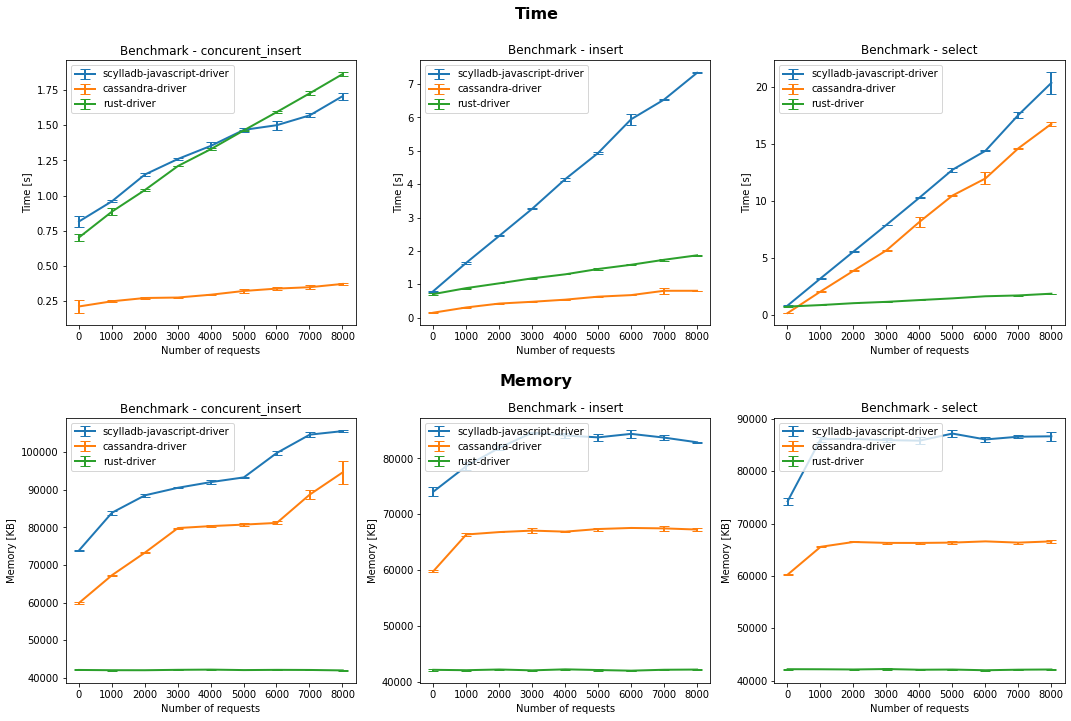

In [10]:
libs.append("rust-driver")

cols = 3
rows_time = (len(df) + cols - 1) // cols
rows_mem = (len(df_mem) + cols - 1) // cols
total_rows = rows_time + rows_mem

fig, axes = plt.subplots(total_rows, cols, figsize=(15, 5 * total_rows), facecolor="white")
axes = axes.flatten()

# ---  Time ---
fig.text(0.5, 0.98, "Time", ha="center", fontsize=16, fontweight="bold")
for i, (test_name, data) in enumerate(df.items()):
    ax = axes[i]
    ax.set_facecolor("white")
    
    for lib in libs:
        data[f"{lib}_mean"] = data[lib].apply(np.mean)
        data[f"{lib}_std"] = data[lib].apply(np.std)
        ax.errorbar(data["n"], data[f"{lib}_mean"], yerr=data[f"{lib}_std"],
                    label=lib, linestyle="-", linewidth=2, capsize=5)
    
    ax.set_xlabel("Number of requests")
    ax.set_ylabel("Time [s]")
    ax.set_title(f"Benchmark - {test_name.split('.')[0]}")
    ax.legend()


for j in range(len(df), rows_time * cols):
    axes[j].axis("off")

# --- Memory ---
start = rows_time * cols 
memory_y = 0.47  # np. 0.50 (czy 0.48) – w zależności od liczby wierszy
fig.text(0.5, memory_y, "Memory", ha="center", fontsize=16, fontweight="bold")
for i, (test_name, data) in enumerate(df_mem.items()):
    ax = axes[start + i]
    ax.set_facecolor("white")
    
    for lib in libs:
        data[f"{lib}_mean"] = data[lib].apply(np.mean)
        data[f"{lib}_std"] = data[lib].apply(np.std)
        ax.errorbar(data["n"], data[f"{lib}_mean"], yerr=data[f"{lib}_std"],
                    label=lib, linestyle="-", linewidth=2, capsize=5)
    
    ax.set_xlabel("Number of requests")
    ax.set_ylabel("Memory [MB]")  
    ax.set_title(f"Benchmark - {test_name.split('.')[0]}")
    ax.legend()

for j in range(start + len(df_mem), total_rows * cols):
    axes[j].axis("off")

plt.style.use('default')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(hspace=0.35)
plt.savefig("graph.svg", format="svg", dpi=300)
plt.show()
